# 2025/AM04 – Dataset Augmentation for Additive Manufacturing defect detection

# Before starting...

## Clone GithHub repo

In [ ]:
import os

if not os.path.exists("/content/mla-prj-23-project-am04_group-am01") and not os.path.exists("/content/mla_project"):
  # DON'T SHARE THE PERSONAL ACCESS TOKEN

  # change the name of the branch here as needed
  !git clone -b main https://github.com/MLinApp-polito/mla-prj-23-project-am04_group-am01.git

  # Rename folder for simplicity
  !mv /content/mla-prj-23-project-am04_group-am01 /content/mla_project

!cd /content/mla_project && git pull

## Install Dependencies

In [ ]:
!pip install torch torchvision matplotlib tqdm lpips

## Imports

In [3]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Classifier on Original dataset

## Dataset mean and std

In [ ]:
!python /content/mla_project/src/data_loader.py --data-dir /content/mla_project/images/original --compute-stats

Dataset mean (grayscale): 0.5839
Dataset std (grayscale): 0.2074


## Training - no augmentation

**IMPORTANT:**

- To perform K-Fold cross-validation, set `--is_kfold` to "True" and specify the number of folds with --k-folds.
    - Example: --is_kfold "True", --k-folds 5

- To perform a single train/val split, set `--is_kfold` to "False" and specify the validation split ratio with `--val-split`.
    - Example: --is_kfold "False", --val-split 0.2

- In both cases, to perform also testing, set `--test` to "True" and specify the test split ratio with `--test-split`.
    - Example: --test "True", --test-split 0.2

### Define paths and parameters

In [4]:
data_dir = '/content/mla_project/images/original'

# Training params
batch_size = 4
epochs = 50
learning_rate = 1e-3
backbone = 'resnet18'
device = 'cuda' if __import__('torch').cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


### Launch training

In [5]:
# k-fold cross validation (with test)

!python /content/mla_project/src/train.py \
    --data-dir "{data_dir}" \
    --batch-size {batch_size} \
    --epochs {epochs} \
    --lr {learning_rate} \
    --backbone {backbone} \
    --num-workers 2 \
    --is_kfold "True" \
    --k-folds 5 \
    --pretrained "False" \
    --test "True" \
    --test-split 0.2

Training with K-Fold cross-validation
Using device: cuda

===== Fold 1 =====

[Fold 1] Number of training images: 51
[Fold 1] Number of validation images: 13
Pretrained weights
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100% 44.7M/44.7M [00:00<00:00, 202MB/s]
[Fold 1] Epoch 1/50 | Train Loss: 0.4256, Acc: 0.9412 | Val Loss: 3.5887, Acc: 0.6154, Precision: 0.3787, Recall: 0.6154, F1: 0.4689
[Fold 1] Epoch 2/50 | Train Loss: 0.2395, Acc: 0.9020 | Val Loss: 2.4057, Acc: 0.6154, Precision: 0.3787, Recall: 0.6154, F1: 0.4689
[Fold 1] Epoch 3/50 | Train Loss: 0.1050, Acc: 0.9608 | Val Loss: 3.2315, Acc: 0.6154, Precision: 0.3787, Recall: 0.6154, F1: 0.4689
[Fold 1] Epoch 4/50 | Train Loss: 0.1602, Acc: 0.9216 | Val Loss: 0.1433, Acc: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
[Fold 1] Epoch 5/50 | Train Loss: 0.1059, Acc: 0.9216 | Val Loss: 0.0869, Acc: 1.0000, Precision: 1.0000, Recall: 1.00

### Plot Training & Validation Curves

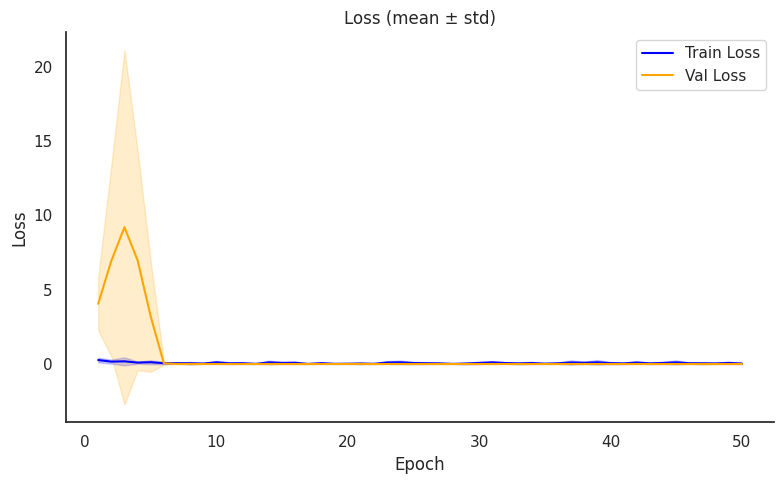

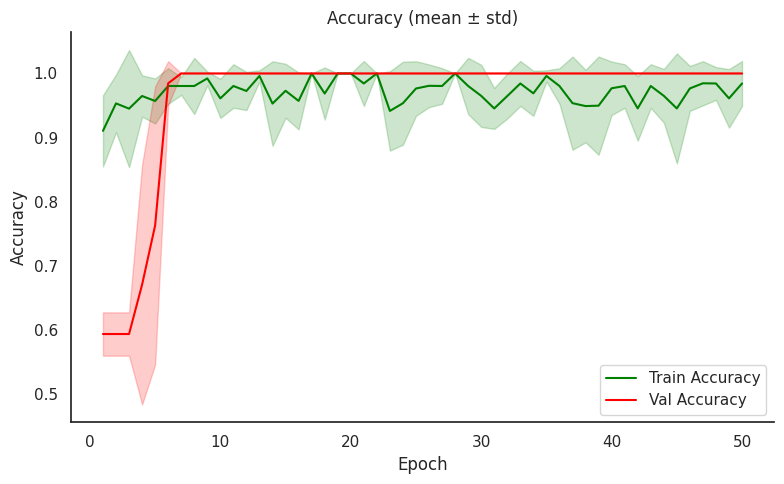

In [6]:
# plot for cross-validation
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read logs
logs = pd.read_csv('/content/kfold_logs.csv')

# Group for epoch and get mean and std
grouped = logs.groupby('epoch').agg({
    'train_loss': ['mean', 'std'],
    'val_loss': ['mean', 'std'],
    'train_acc': ['mean', 'std'],
    'val_acc': ['mean', 'std']
}).reset_index()

# Rename columns
grouped.columns = ['epoch',
                   'train_loss_mean', 'train_loss_std',
                   'val_loss_mean', 'val_loss_std',
                   'train_acc_mean', 'train_acc_std',
                   'val_acc_mean', 'val_acc_std']

# Set style
sns.set(style="white", context="notebook")

# LOSS
plt.figure(figsize=(8, 5))
plt.plot(grouped['epoch'], grouped['train_loss_mean'], label='Train Loss', color='blue')
plt.fill_between(grouped['epoch'],
                 grouped['train_loss_mean'] - grouped['train_loss_std'],
                 grouped['train_loss_mean'] + grouped['train_loss_std'],
                 color='blue', alpha=0.2)

plt.plot(grouped['epoch'], grouped['val_loss_mean'], label='Val Loss', color='orange')
plt.fill_between(grouped['epoch'],
                 grouped['val_loss_mean'] - grouped['val_loss_std'],
                 grouped['val_loss_mean'] + grouped['val_loss_std'],
                 color='orange', alpha=0.2)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss (mean ± std)')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

# ACCURACY
plt.figure(figsize=(8, 5))
plt.plot(grouped['epoch'], grouped['train_acc_mean'], label='Train Accuracy', color='green')
plt.fill_between(grouped['epoch'],
                 grouped['train_acc_mean'] - grouped['train_acc_std'],
                 grouped['train_acc_mean'] + grouped['train_acc_std'],
                 color='green', alpha=0.2)

plt.plot(grouped['epoch'], grouped['val_acc_mean'], label='Val Accuracy', color='red')
plt.fill_between(grouped['epoch'],
                 grouped['val_acc_mean'] - grouped['val_acc_std'],
                 grouped['val_acc_mean'] + grouped['val_acc_std'],
                 color='red', alpha=0.2)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy (mean ± std)')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()


## Training - basic augmentations (simple transformations)

In [7]:
data_dir = '/content/mla_project/images/original'

# Training params
batch_size = 4
epochs = 50
learning_rate = 1e-3
backbone = 'resnet18'
device = 'cuda' if __import__('torch').cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


In [8]:
# k-fold cross validation (with test) with augmented data

!python /content/mla_project/src/train.py \
    --data-dir "{data_dir}" \
    --batch-size {batch_size} \
    --epochs {epochs} \
    --lr {learning_rate} \
    --backbone {backbone} \
    --num-workers 2 \
    --is_kfold "True" \
    --k-folds 5 \
    --test "True" \
    --test-split 0.2 \
    --aug "True"

Training with K-Fold cross-validation
Using device: cuda

===== Fold 1 =====

[Fold 1] Number of training images: 51
[Fold 1] Number of validation images: 13
Pretrained weights
[Fold 1] Epoch 1/50 | Train Loss: 0.5093, Acc: 0.7255 | Val Loss: 19.1339, Acc: 0.6154, Precision: 0.3787, Recall: 0.6154, F1: 0.4689
[Fold 1] Epoch 2/50 | Train Loss: 0.3296, Acc: 0.8824 | Val Loss: 8.8388, Acc: 0.6154, Precision: 0.3787, Recall: 0.6154, F1: 0.4689
[Fold 1] Epoch 3/50 | Train Loss: 0.1526, Acc: 0.9216 | Val Loss: 3.1587, Acc: 0.6154, Precision: 0.3787, Recall: 0.6154, F1: 0.4689
[Fold 1] Epoch 4/50 | Train Loss: 0.0184, Acc: 1.0000 | Val Loss: 0.6758, Acc: 0.6154, Precision: 0.3787, Recall: 0.6154, F1: 0.4689
[Fold 1] Epoch 5/50 | Train Loss: 0.0346, Acc: 0.9804 | Val Loss: 0.0086, Acc: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
[Fold 1] Epoch 6/50 | Train Loss: 0.2209, Acc: 0.9412 | Val Loss: 0.0024, Acc: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
[Fold 1] Epoch 7/50 | Tr

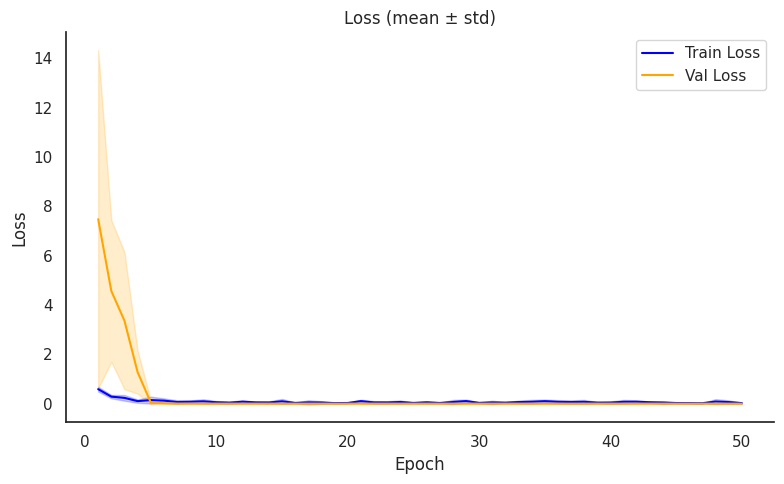

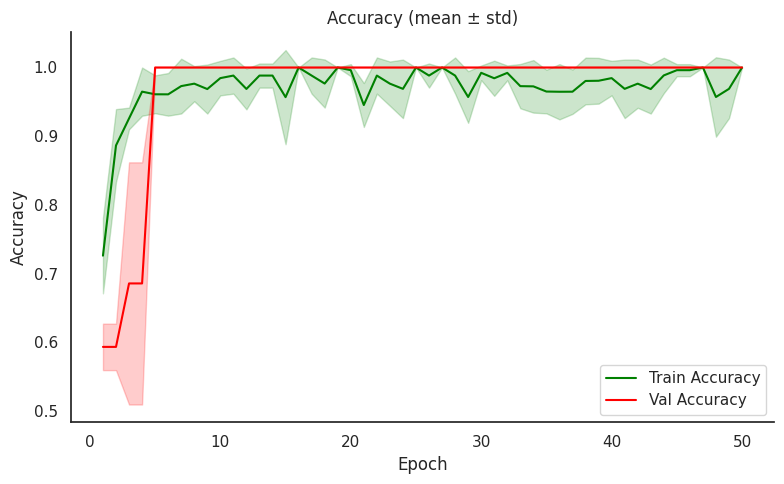

In [9]:
# Read logs
logs = pd.read_csv('/content/kfold_logs.csv')

# Group for epoch and get mean and std
grouped = logs.groupby('epoch').agg({
    'train_loss': ['mean', 'std'],
    'val_loss': ['mean', 'std'],
    'train_acc': ['mean', 'std'],
    'val_acc': ['mean', 'std']
}).reset_index()

# Rename columns
grouped.columns = ['epoch',
                   'train_loss_mean', 'train_loss_std',
                   'val_loss_mean', 'val_loss_std',
                   'train_acc_mean', 'train_acc_std',
                   'val_acc_mean', 'val_acc_std']

# Set style
sns.set(style="white", context="notebook")

# LOSS
plt.figure(figsize=(8, 5))
plt.plot(grouped['epoch'], grouped['train_loss_mean'], label='Train Loss', color='blue')
plt.fill_between(grouped['epoch'],
                 grouped['train_loss_mean'] - grouped['train_loss_std'],
                 grouped['train_loss_mean'] + grouped['train_loss_std'],
                 color='blue', alpha=0.2)

plt.plot(grouped['epoch'], grouped['val_loss_mean'], label='Val Loss', color='orange')
plt.fill_between(grouped['epoch'],
                 grouped['val_loss_mean'] - grouped['val_loss_std'],
                 grouped['val_loss_mean'] + grouped['val_loss_std'],
                 color='orange', alpha=0.2)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss (mean ± std)')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

# ACCURACY
plt.figure(figsize=(8, 5))
plt.plot(grouped['epoch'], grouped['train_acc_mean'], label='Train Accuracy', color='green')
plt.fill_between(grouped['epoch'],
                 grouped['train_acc_mean'] - grouped['train_acc_std'],
                 grouped['train_acc_mean'] + grouped['train_acc_std'],
                 color='green', alpha=0.2)

plt.plot(grouped['epoch'], grouped['val_acc_mean'], label='Val Accuracy', color='red')
plt.fill_between(grouped['epoch'],
                 grouped['val_acc_mean'] - grouped['val_acc_std'],
                 grouped['val_acc_mean'] + grouped['val_acc_std'],
                 color='red', alpha=0.2)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy (mean ± std)')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

# Generative Models

## SinGANs

### Training - SinGAN

In this phase, a **SinGAN** model is trained using a single image selected by the user from the original dataset.

To train a SinGAN model on a single image, the following parameters are configured:

- `input_dir`: Specifies the directory containing the original images, organized `y` class ("Defects" or "NoDefects").
- `class_`: Indicates the specific image class used for training (Defects or NoDefects).
- `input_name`: Defines the name of the original image file to be used as the training input.
- `mode`: Sets the execution mode of the script. When set to 'train', it triggers the `raining process.
- `scale_factor`: Controls the downscaling applied between successive image pyramid levels (a higher value results in more levels and finer structural representation).
- `niter`: Specifies the number of training iterations per pyramid level.
- `lr_g` and `lr_d`: Define the learning rates for the generator and discriminator networks, respectively.
- `Gsteps` and `Dsteps`: Indicate how many optimization steps are performed for the generator and discriminator at each scale.

In [ ]:
# input directory of the original images
input_dir = "/content/mla_project/images/original"

# Set parameters for training
class_ = "Defects"
image_name = "Image0.jpg"
mode = 'train'
scale_factor = 0.80
niter = 2000
lr_g = 0.0005
lr_d = 0.0005
G_steps = 5
D_steps = 5

# Train the SinGAN model on the specified image
!python /content/mla_project/generative_models/SinGAN/main_train.py  --input_dir "{input_dir}/{class_}/" \
                                                            --class_ "{class_}" \
                                                            --input_name "{image_name}" \
                                                            --mode '{mode}' \
                                                            --scale_factor {scale_factor} \
                                                            --niter {niter} \
                                                            --lr_g {lr_g} \
                                                            --lr_d {lr_d} \
                                                            --Gsteps {G_steps} \
                                                            --Dsteps {D_steps} \

### Generate new images using SinGAN

In this phase, random samples are generated using the SinGAN model for the specified image and class.

NB: Modify the `--gen_start_scale 0` parameter to start from a different scale during generation of images.

In [ ]:
class_samples = "Defects"          # Class label or category of the image
image_name_samples = "Image0.jpg"   # Filename of the input image to be used for generate samples
scale_factor = 0.80

# Generate random samples using the SinGAN model for the specified image and class
!python /content/mla_project/generative_models/SinGAN/random_samples.py --input_dir "{input_dir}/{class_samples}/" \
                                                      --class_ "{class_samples}" \
                                                      --input_name "{image_name_samples}" \
                                                      --mode random_samples \
                                                      --scale_factor {scale_factor} \
                                                      --gen_start_scale 0

## GANs

### Training - GAN

In this phase, a **GAN** model is trained on a single class—either `Defects` or `NoDefects` from the original dataset. The training process is controlled by a series of parameters that define how the model learns:

- `--generate_defect`: a flag indicating which class to use for training. If set, the model is trained on images from the `Defects` folder; otherwise, it will default to `NoDefects`.
- `--data_dir`: the path to the folder containing the training images for the selected class.
- `--batch_size`: the number of images processed in each training iteration.
- `--n_epochs`: the total number of training epochs.
- `--img_size`: all images are resized to this dimension.
- `--sample_interval`: controls how often (in training steps) the model saves generated image samples.


In [ ]:
!python /content/mla_project/generative_models/GANs/gan.py \
    --generate_defect \
    --data_dir "/content/mla_project/images/original/Defects" \
    --batch_size 4 \
    --n_epochs 10 \
    --img_size 512 \
    --sample_interval 400

### Generate new images using GANs

In [ ]:
!python /content/mla_project/generative_models/GANs/generate.py \
      --model_path "/content/saved_models/generator_epoch_0.pth" \
      --img_size 512 \
      --num_images 10 \
      --output_dir "/content/generated_images"

## Diffusion Models

In this phase, a **Diffusion Model** is used to generate synthetic grayscale images of metallic powder bed surfaces, mimicking conditions from an Additive Manufacturing (AM) process. The model operates using text-guided generation with both a positive and a negative prompt to control the visual content of the outputs.

### Clone repo and install packages

In [ ]:
%cd /content/mla_project/generative_models/Diffusion
!git clone https://github.com/huggingface/diffusers
%cd diffusers
!pip install .
!pip install --upgrade diffusers[torch]
!pip install diffusers transformers accelerate scipy safetensors controlnet_aux --upgrade
!pip install -r /content/mla_project/generative_models/Diffusion/diffusers/examples/dreambooth/requirements.txt
!pip install peft==0.15.1
!pip install bitsandbytes

### Generated Images Using Pretrained Model

Before performing any fine-tuning, the capabilities of a pretrained **Stable Diffusion v1.5** model are assessed in the context of metal additive manufacturing imagery.

This technique serves as a baseline to evaluate how well a general-purpose diffusion model can adapt to a niche industrial domain like PBF imagery without any domain-specific fine-tuning. The resulting images provide insight into the limitations and strengths of pretrained generative models in specialized applications.

The parameters to generate synthetic images are:
- `prompt`: the positive textual description used to guide image generation.
- `negative_prompt`: a list of undesirable features the model should avoid, such as "artistic", "cartoon", or "color".
- `input_root`: the directory containing the original grayscale input images.
- `output_root`: the path where the generated images will be saved.
- `strength`: controls how strongly the prompt influences the original image. A value of `0.25` indicates that only subtle modifications are applied, preserving much of the original image’s structure.
- `guidance_scale`: determines the weight of the text prompt during generation. A higher value (e.g., `5.0`) enforces stronger alignment to the given prompt.
- `num_images_per_input`: the number of synthetic images to generate for each input.


#### Generate from all the images

In [ ]:
prompt = (
    "A high-resolution grayscale technical photo of a metallic powder bed surface in a metal additive manufacturing process, "
    "with some localized defects (such as spattering, holes, or uneven lines) that have been modified in shape, position, or appearance, "
    "or newly introduced in realistic ways. The metallic texture and background should remain unchanged, with consistent lighting and flat structure."
)

negative_prompt = "artistic, painting, illustration, cartoon, abstract, low quality, blurry, distorted, unrealistic, fantasy, 3d render, color, oversaturated, text, watermark, logo"


!python /content/mla_project/generative_models/Diffusion/generate.py \
    --input_root "/content/mla_project/images/original" \
    --output_root "/content/generated_images_pretrained" \
    --prompt prompt \
    --negative_prompt negative_prompt \
    --strength 0.25 \
    --guidance_scale 5.0 \
    --num_images_per_input 1

#### Generate from a single images

In [ ]:
prompt = (
    "A high-resolution grayscale technical photo of a metallic powder bed surface in a metal additive manufacturing process, "
    "with some localized defects (such as spattering, holes, or uneven lines) that have been modified in shape, position, or appearance, "
    "or newly introduced in realistic ways. The metallic texture and background should remain unchanged, with consistent lighting and flat structure."
)

negative_prompt = "artistic, painting, illustration, cartoon, abstract, low quality, blurry, distorted, unrealistic, fantasy, 3d render, color, oversaturated, text, watermark, logo"


!python /content/mla_project/generative_models/Diffusion/generate.py \
    --path_single_image "/content/mla_project/images/original/Defects/Image2.jpg" \
    --output_root "/content/generated_single_images_pretrained" \
    --prompt prompt \
    --negative_prompt negative_prompt \
    --strength 0.25 \
    --guidance_scale 5.0 \
    --num_images_per_input 1

### Generate images using fine-tuned model

In this phase, the pre-trained **Stable Diffusion v1.5** model is fine-tuned using **LoRA (Low-Rank Adaptation)** on domain-specific grayscale images from a Powder Bed Fusion (PBF) process. The goal is to adapt the generative model to better synthesize high-resolution, technical images of metal powder beds, distinguishing between defect and no-defect conditions.

The parameters to generate synthetic images are:
- `prompt`: the positive textual description used to guide image generation.
- `negative_prompt`: a list of undesirable features the model should avoid, such as "artistic", "cartoon", or "color".
- `input_root`: the directory containing the original grayscale input images.
- `output_root`: the path where the generated images will be saved.
- `strength`: controls how strongly the prompt influences the original image. A value of `0.25` indicates that only subtle modifications are applied, preserving much of the original image’s structure.
- `guidance_scale`: determines the weight of the text prompt during generation. A higher value (e.g., `5.0`) enforces stronger alignment to the given prompt.
- `num_images_per_input`: the number of synthetic images to generate for each input.

#### Fine-tune LoRa

The fine-tuning process is guided by two types of image sets:

- `instance_data_dir`: contains real images with **defects**, used to specialize the model on generating or manipulating visible anomalies on the powder bed.
- `class_data_dir`: contains images from the **NoDefects** category, used for regularization via prior preservation to maintain the model's generalization capabilities.

The text prompts define the intended appearance for each category:
- `instance_prompt`: instructs the model to learn to modify or insert small localized anomalies while preserving the realistic metallic texture and background.
- `class_prompt`: represents the general appearance of a smooth, defect-free powder bed surface.

The most relevant training parameters are:
- `resolution`: input image resolution during training.
- `train_batch_size`: batch size per iteration.
- `learning_rate`: learning rate for fine-tuning.
- `num_class_images`: number of class images to generate (if needed) for prior preservation.
- `max_train_steps`: total training steps.
- `checkpointing_steps`: intermediate model checkpoints saved every 400 steps.
- `rank`: LoRA rank, which controls the number of trainable parameters added to each layer.
- `lora_dropout`: dropout applied to LoRA layers for regularization.
- `train_text_encoder`: enables fine-tuning of the text encoder alongside the UNet.

Mixed precision (`fp16`) and 8-bit Adam optimizer are used to reduce memory footprint and speed up training. This configuration allows for efficient, lightweight domain adaptation of the diffusion model while retaining general image generation capabilities.


In [ ]:
!accelerate launch /content/mla_project/generative_models/Diffusion/diffusers/examples/dreambooth/train_dreambooth_lora.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --instance_data_dir="/content/mla_project/images/original/Defects" \
  --class_data_dir="/content/mla_project/images/original/NoDefects" \
  --output_dir="/content/lora_trained_model" \
  --instance_prompt="A high-resolution grayscale technical photo of a metallic powder bed surface in a metal additive manufacturing process, with localized objects that should be modified or added randomly across the surface, while keeping the high quality of background and overall scene unchanged. The texture should remain flat and metallic, with no changes to the background, lighting, or general structure." \
  --class_prompt="a grayscale technical photo of a uniform powder bed surface in a metal additive manufacturing process, flat and smooth texture, no visible defects, high-resolution" \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=1 \
  --learning_rate=1e-5 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --num_class_images=100 \
  --max_train_steps=1000 \
  --checkpointing_steps=400 \
  --seed=42 \
  --mixed_precision="fp16" \
  --use_8bit_adam \
  --rank=16 \
  --lora_dropout=0.1 \
  --train_text_encoder


#### Generate from all the images

In [ ]:
prompt = (
    "A high-resolution grayscale technical photo of a metallic powder bed surface in a metal additive manufacturing process, "
    "with some localized defects (such as spattering, holes, or uneven lines) that have been modified in shape, position, or appearance, "
    "or newly introduced in realistic ways. The metallic texture and background should remain unchanged, with consistent lighting and flat structure."
)

negative_prompt = "artistic, painting, illustration, cartoon, abstract, low quality, blurry, distorted, unrealistic, fantasy, 3d render, color, oversaturated, text, watermark, logo"

#CHECK LORA PATH
!python /content/mla_project/generative_models/Diffusion/generate.py \
    --lora_weights_path "/content/lora_trained_model/pytorch_lora_weights.safetensors" \
    --input_root "/content/mla_project/images/metrics-original" \
    --output_root "/content/generated_images_fine_tuned" \
    --prompt "{prompt}" \
    --negative_prompt "{negative_prompt}" \
    --strength 0.20 \
    --guidance_scale 12.0 \
    --num_images_per_input 7

#### Generate from a single images

In [ ]:
prompt = (
    "A high-resolution grayscale technical photo of a metallic powder bed surface in a metal additive manufacturing process, "
    "with some localized defects (such as spattering, holes, or uneven lines) that have been modified in shape, position, or appearance, "
    "or newly introduced in realistic ways. The metallic texture and background should remain unchanged, with consistent lighting and flat structure."
)

negative_prompt = "artistic, painting, illustration, cartoon, abstract, low quality, blurry, distorted, unrealistic, fantasy, 3d render, color, oversaturated, text, watermark, logo"


!python /content/mla_project/generative_models/Diffusion/generate.py \
    --lora_weights_path "/content/lora_trained_model/pytorch_lora_weights.safetensors" \
    --path_single_image "/content/mla_project/images/original/Defects/Image2.jpg" \
    --output_root "/content/generated_single_images_fine_tuned" \
    --prompt prompt \
    --negative_prompt negative_prompt \
    --strength 0.25 \
    --guidance_scale 5.0 \
    --num_images_per_input 1

## Conditional VAEs

### Training - Conditional VAE

The training command for the CVAE model includes the following key parameters:

- `data_dir`: specifies the directory containing the input images used for training.

- `batch_size`: defines the batch size.

- `max_epoch`: sets the maximum number of training epochs.

- `latent_size`: determines the size of the latent space, representing the number of latent variables used to encode the images.

- `image_size`: sets the resolution of input images.

- `device "cuda"`: specifies the hardware device to run the training on; here, the GPU is used via CUDA to accelerate computations.

- `load_epoch`: indicates that the model will load weights saved at epoch X, allowing to resume training from that point or evaluate a partially trained model.


In [ ]:
!python /content/mla_project/generative_models/VAEs/train_cvae.py \
        --data_dir "/content/mla_project/images/original" \
        --batch_size 4 \
        --max_epoch 100 \
        --latent_size 128 \
        --image_size 512 \
        --device "cuda" \
        --load_epoch 35

### Generate new images using Conditional VAE

In [ ]:
# Generate images
!python /content/mla_project/generative_models/VAEs/generate.py \
      --checkpoint ./checkpoints/model_99.pt \
      --latent_size 128 \
      --image_size 512 \
      --num_images 10 \
      --device cuda \
      --output_dir generated_images

# VAEs

## Training - VAEs

To train a Variational Autoencoder (VAE) on images from a specific class (e.g., *NoDefects*), the following parameters are used:

* `data_dir`: The path to the dataset directory containing the training images of the target class.
* `class_name`: The class label corresponding to the images used for training.
* `batch_size`: The number of samples processed in each training iteration.
* `max_epoch`: The total number of epochs used to train the model.
* `latent_size`: The dimensionality of the latent vector learned by the encoder.
* `image_size`: The size (in pixels) to which all input images are resized.
* `device`: The hardware device used for training (e.g., CPU or GPU).

In [ ]:
!python /content/mla_project/generative_models/VAEs/train_vae.py \
       --data_dir "/content/mla_project/images/original/NoDefects" \
       --class_name "NoDefects" \
       --batch_size 4 \
       --max_epoch 100 \
       --latent_size 128 \
       --image_size 512 \
       --device "cuda"

## Generate new images using VAE

In [ ]:
!python /content/mla_project/generative_models/VAEs/generate.py \
       --checkpoint ./checkpoints/model_99.pt \
       --latent_size 128 \
       --image_size 512 \
       --num_images 90 \
       --device cuda \
        --output_dir generated_images \
        --model_type "vae"

# Metrics

## L-PIPS

In [ ]:
original_dir = "/content/mla_project/images/original/"
generated_dir = "/content/mla_project/images/augmented/"
model = "GANs"
experiment = "Experiment_1"

!python /content/mla_project/metrics/lpips_score.py --cuda \
                                                --original_dir {original_dir} \
                                                --generated_dir {generated_dir} \
                                                --model {model} \
                                                --experiment {experiment} \

## Inception Score

In [ ]:
base_dir = "/content/mla_project/"
model = "GANs"                  # "original" or "CVAE" or "GANs"
experiment = "Fusion_1_6"       # it doesn't matter if the model is "original"
batch_size = 1
splits = 10

!python /content/mla_project/metrics/inception_score.py --cuda \
                                                        --base_dir {base_dir} \
                                                        --model {model} \
                                                        --experiment {experiment} \
                                                        --batch_size {batch_size} \
                                                        --splits {splits}

## FID

In [ ]:
real_dir = "/content/mla_project/images/original/"
generated_dir = "/content/mla_project/images/augmented/GANs/Fusion_8_9" # directory of the specific experiment
batch_size = 4
class_name = "Defects"  #Defects or NoDefects

!python /content/mla_project/metrics/fid_score.py --use_gpu \
                                                  --real_dir {real_dir} \
                                                  --generated_dir {generated_dir} \
                                                  --batch_size {batch_size} \
                                                  --class_name {class_name}

## GEN_train and GEN_test

In [ ]:
base_dir = "/content/mla_project/"
mode = "GEN_train"                   # "GEN_train" or "GEN_test"
model = "Diffusion"                  # "CVAE" or "GANs"
experiment = "Experiment1"

backbone = "resnet18"
batch_size = 4
val_split = 0.2
num_workers = 2
random_seed = 42
epochs = 50
lr = 0.001

!python /content/mla_project/metrics/gen_train_gen_test.py --cuda \
                                                            --base_dir {base_dir} \
                                                            --mode {mode} \
                                                            --model {model} \
                                                            --experiment {experiment} \
                                                            --backbone {backbone} \
                                                            --pretrained \
                                                            --batch_size {batch_size} \
                                                            --val_split {val_split} \
                                                            --num_workers {num_workers} \
                                                            --random_seed {random_seed} \
                                                            --epochs {epochs} \
                                                            --lr {lr}